# Test

In [20]:
import os
import sys
import torch
import glob
import matplotlib.pyplot as plt
import numpy as np

from config import get_small_config, get_mae_config
from timesformer_mae import TimeSformerMAE
from dataset import ThresholdMAEDataset, create_dataloaders

In [21]:
DATA_ROOT = r"C:\\Users\\shrua\\OneDrive\\Desktop\\threshold project\\threshold\\data"
CANDIDATES_FOLDER = os.path.join(DATA_ROOT, 'candidates')
PANO_FOLDER = os.path.join(DATA_ROOT, 'panos')

csv_files = glob.glob(os.path.join(CANDIDATES_FOLDER, '*_thresholds.csv'))
print(f"\nFound {len(csv_files)} threshold CSV files")


Found 40 threshold CSV files


In [22]:
dataset = ThresholdMAEDataset(csv_files, PANO_FOLDER)
print(f"\nDataset size: {len(dataset)} sequences")

Loaded 10474 threshold sequences from 40 files

Dataset size: 10474 sequences


In [23]:
# Load first sample
sample = dataset[0]

print(f"\nSample structure:")
print(f"  pixel_values shape: {sample['pixel_values'].shape}")
print(f"  pixel_values dtype: {sample['pixel_values'].dtype}")
print(f"  pixel_values range: [{sample['pixel_values'].min():.3f}, {sample['pixel_values'].max():.3f}]")
print(f"  label: {sample['labels']} (typology class)")
print(f"  metadata: {sample['metadata']}")


Sample structure:
  pixel_values shape: torch.Size([7, 3, 32, 64])
  pixel_values dtype: torch.float32
  pixel_values range: [0.000, 1.000]
  label: 0 (typology class)
  metadata: {'typology': 't1-1', 'curve': 'curve_00', 'candidate_frame': np.int64(11), 'window_start': np.int64(8), 'window_end': np.int64(14)}


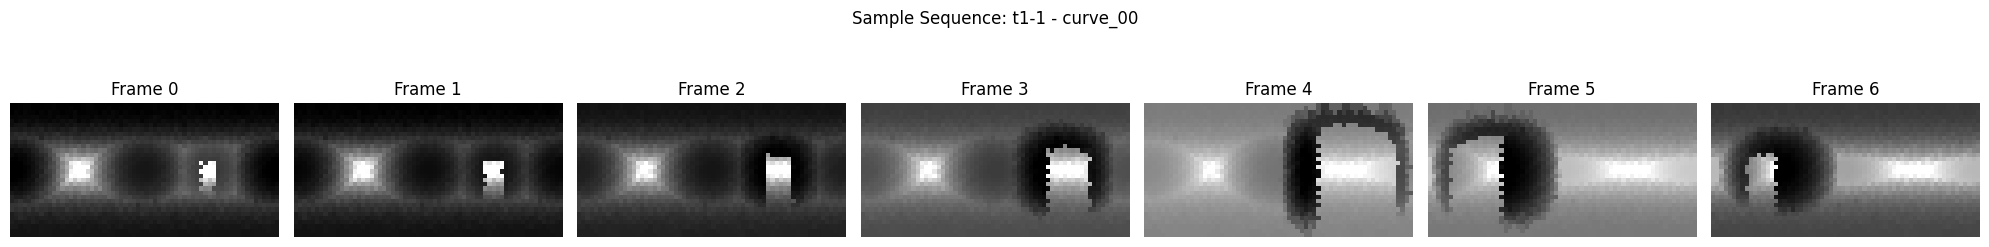

In [24]:
# Visualize first sequence
frames = sample['pixel_values']  # (7, 3, 32, 64)

fig, axes = plt.subplots(1, 7, figsize=(20, 3))
for i in range(7):
    # Take first channel (all 3 channels are identical for grayscale)
    img = frames[i, 0].numpy()
    axes[i].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f'Frame {i}')
    axes[i].axis('off')

plt.suptitle(f"Sample Sequence: {sample['metadata']['typology']} - {sample['metadata']['curve']}")
plt.tight_layout()
plt.show()

In [25]:
config = get_small_config()

model = TimeSformerMAE(config)

num_params = sum(p.numel() for p in model.parameters())
print(f"  Total parameters: {num_params:,}")
print(f"  Encoder parameters: {sum(p.numel() for p in model.encoder.parameters()):,}")
print(f"  Decoder parameters: {sum(p.numel() for p in model.decoder.parameters()):,}")

Configuration:
  Image size: 32x64
  Patch size: 4x4
  Patches per frame: 128 (8x16)
  Total frames: 7
  Total patches: 896
  Visible patches (~10%): ~89
  Masked patches (~90%): ~806
  Total parameters: 5,531,824
  Encoder parameters: 4,980,992
  Decoder parameters: 550,576


In [26]:
# Create dummy batch
batch_size = 2
dummy_input = torch.randn(batch_size, 7, 3, 32, 64)

print(f"Input shape: {dummy_input.shape}")

with torch.no_grad():
    loss, pred, mask = model(dummy_input)

print(f"  Loss: {loss.item():.4f}")
print(f"  Prediction shape: {pred.shape}")
print(f"  Mask shape: {mask.shape}")
print(f"  Mask ratio: {mask.float().mean().item():.2%} (target: 90%)")

Input shape: torch.Size([2, 7, 3, 32, 64])
  Loss: 1.0453
  Prediction shape: torch.Size([2, 896, 48])
  Mask shape: torch.Size([2, 896])
  Mask ratio: 90.07% (target: 90%)


In [27]:
# Create dataloader with small batch
print("Creating dataloaders...")
train_loader, val_loader = create_dataloaders(
    data_root=DATA_ROOT,
    batch_size=2,
    train_split=0.85,
    num_workers=0,
)

print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

Creating dataloaders...
Found 40 threshold CSV files
Loaded 10474 threshold sequences from 40 files
Train size: 8902, Val size: 1572
  Train batches: 4451
  Val batches: 786


In [28]:
# Get one batch
batch = next(iter(train_loader))
pixel_values = batch['pixel_values']

print(f"Batch shape: {pixel_values.shape}")
print(f"Labels: {batch['labels']}")

# Create optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

# Training step
loss, pred, mask = model(pixel_values)
print(f"  Forward pass - Loss: {loss.item():.4f}")

optimizer.zero_grad()
loss.backward()

optimizer.step()


Batch shape: torch.Size([2, 7, 3, 32, 64])
Labels: tensor([6, 3])
  Forward pass - Loss: 1.0376
